# Flight Delay Project — Analysis & Insights

In this notebook, we analyze the cleaned and feature-engineered flight dataset to uncover meaningful patterns and insights.

We will:
- explore when delays happen (time patterns)
- analyze which airports and airlines contribute most to delays
- break down delay causes
- identify patterns that explain why delays occur

The goal is not just visualization, but to generate clear, explainable insights from the data.

In [1]:
import pandas as pd
from pathlib import Path

project_root = Path().resolve().parent
data_path = project_root / "data" / "processed" / "flights_featured.csv"

df = pd.read_csv(data_path)

df.head()

,FL_DATE,AIRLINE,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,DIVERTED,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,month,day_of_week,is_weekend,delay_flag,delay_category,route,total_delay_components
0,2019-01-09,United Air Lines Inc.,FLL,EWR,-4.0,-14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,0,0,On Time,FLL-EWR,0.0
1,2022-11-19,Delta Air Lines Inc.,MSP,SEA,-6.0,-5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11,5,1,0,On Time,MSP-SEA,0.0
2,2022-07-22,United Air Lines Inc.,DEN,MSP,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,4,0,0,On Time,DEN-MSP,0.0
3,2023-03-06,Delta Air Lines Inc.,MSP,SFO,-1.0,24.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,3,0,0,1,Moderate Delay,MSP-SFO,24.0
4,2020-02-23,Spirit Air Lines,MCO,DFW,-2.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,6,1,0,On Time,MCO-DFW,0.0


In [2]:
print("Shape:", df.shape)

print("\nDelay rate:")
print(df['delay_flag'].value_counts(normalize=True))

Shape: (2913802, 20)

Delay rate:
delay_flag
0    0.823156
1    0.176844
Name: proportion, dtype: float64


## Time-Based Delay Patterns

We analyze how delays vary across time:
- by month
- by day of week
- weekend vs weekday

This helps identify temporal trends in flight delays.

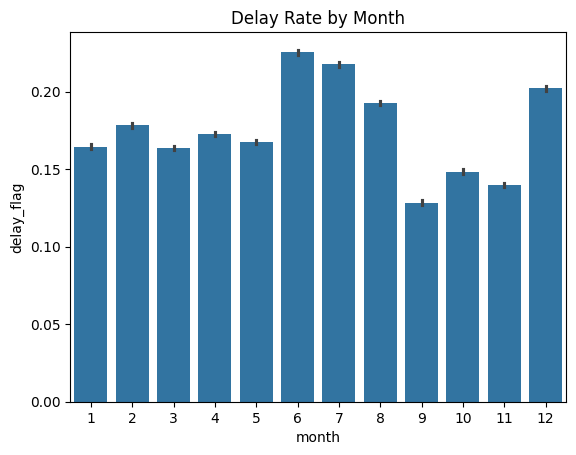

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Delay by month
sns.barplot(x='month', y='delay_flag', data=df)
plt.title("Delay Rate by Month")
plt.show()

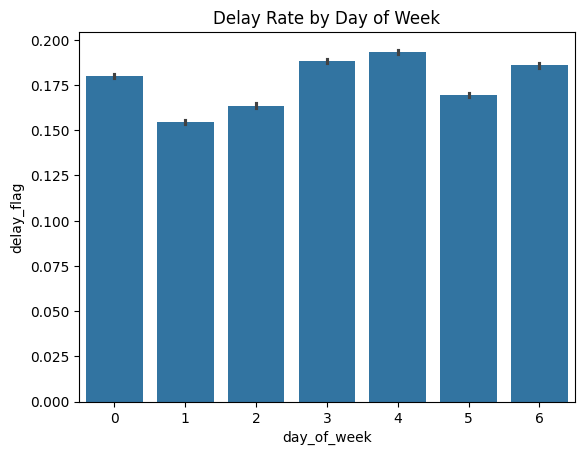

In [5]:
# Delay by day of week
sns.barplot(x='day_of_week', y='delay_flag', data=df)
plt.title("Delay Rate by Day of Week")
plt.show()

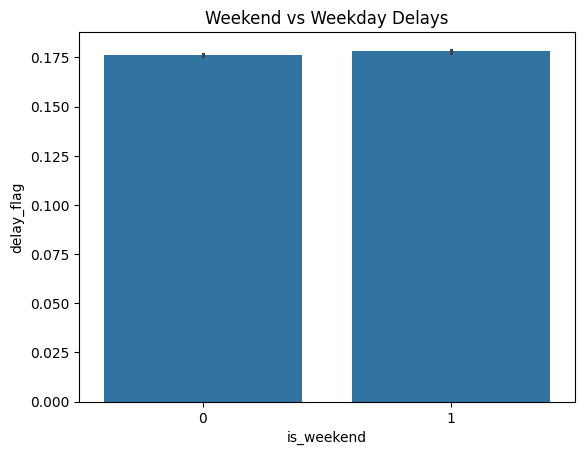

In [6]:
# Weekend vs weekday
sns.barplot(x='is_weekend', y='delay_flag', data=df)
plt.title("Weekend vs Weekday Delays")
plt.show()

## Airport-Level Analysis

We analyze which airports contribute most to delays.

We use average arrival delay and delay rate to identify problematic airports.

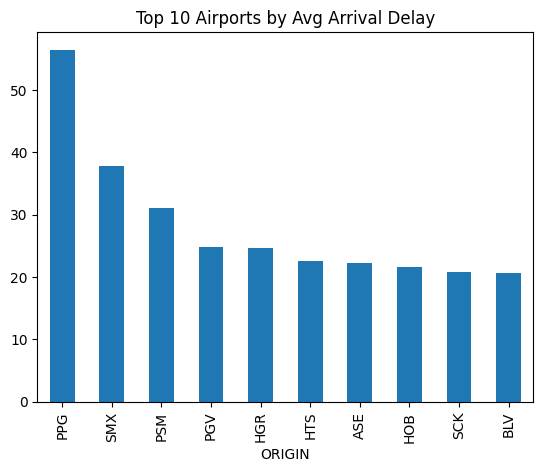

In [4]:
# Top 10 airports by average delay
top_airports = (
    df.groupby('ORIGIN')['ARR_DELAY']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_airports.plot(kind='bar', title="Top 10 Airports by Avg Arrival Delay")
plt.show()

## Airline Performance Analysis

We compare airlines based on:
- average delay
- delay frequency

This helps identify which airlines are more reliable.

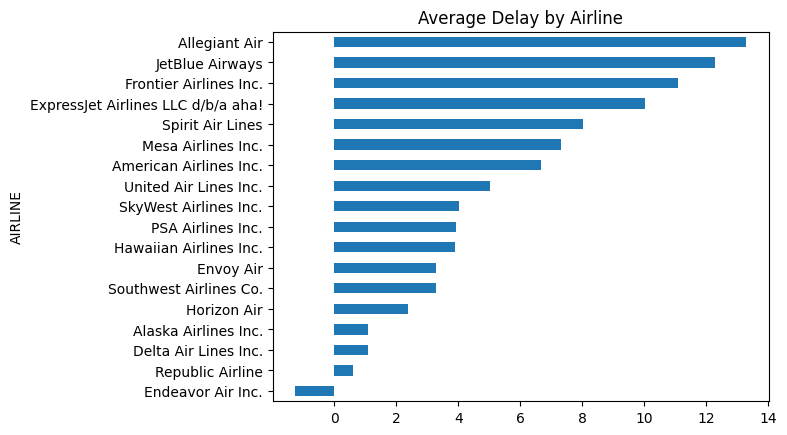

In [7]:
airline_delay = (
    df.groupby('AIRLINE')['ARR_DELAY']
    .mean()
    .sort_values()
)

airline_delay.plot(kind='barh', title="Average Delay by Airline")
plt.show()

## Delay Cause Breakdown

We analyze the contribution of different delay causes:
- carrier issues
- weather
- air traffic (NAS)
- late aircraft

This helps explain WHY delays occur.

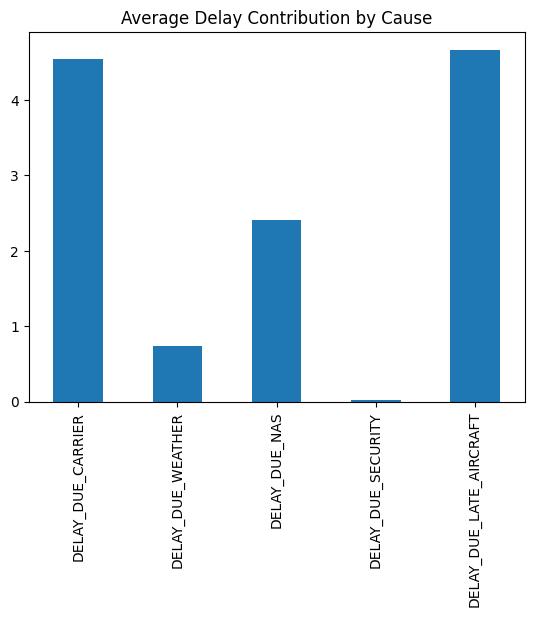

In [8]:
delay_cols = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

df[delay_cols].mean().plot(kind='bar', title="Average Delay Contribution by Cause")
plt.show()

## Delay Severity Distribution

We analyze how delays are distributed:
- most flights are on time or slightly delayed
- a small number experience severe delays

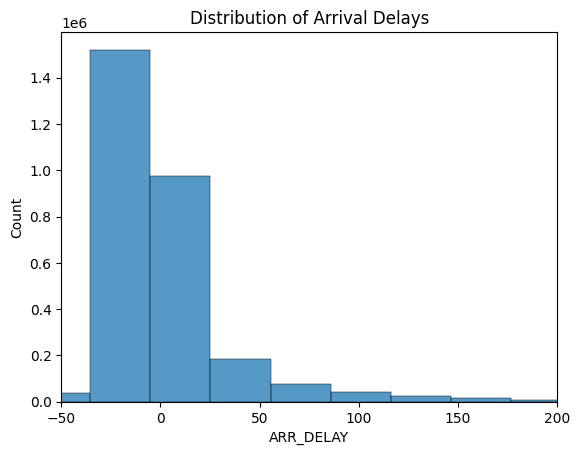

In [9]:
sns.histplot(df['ARR_DELAY'], bins=100)
plt.xlim(-50, 200)
plt.title("Distribution of Arrival Delays")
plt.show()

## Key Insight Exploration

We investigate whether departure delays translate into arrival delays.

This helps understand delay propagation.

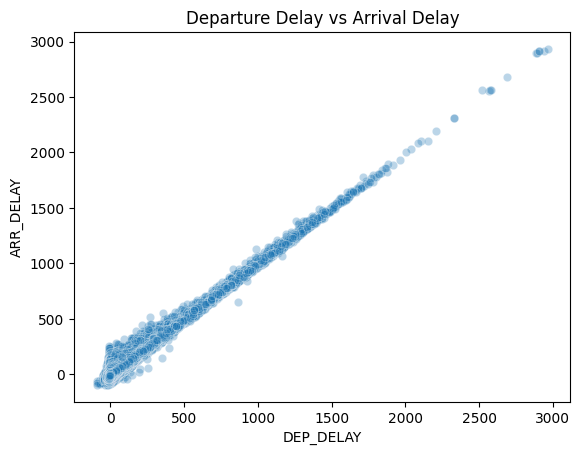

In [10]:
sns.scatterplot(x='DEP_DELAY', y='ARR_DELAY', data=df, alpha=0.3)
plt.title("Departure Delay vs Arrival Delay")
plt.show()

## Key Insights

1. Flight delays peak during summer months (June–July) due to increased demand.
2. Delays tend to increase toward the end of the week, indicating operational buildup.
3. Weekend vs weekday delays are nearly identical, suggesting consistent system load.
4. Certain airports experience disproportionately high delays, not necessarily the busiest ones.
5. Low-cost airlines tend to have higher delays compared to premium carriers.
6. Most delays are caused by operational factors (carrier + late aircraft), not external factors.
7. Delay distribution is heavily right-skewed, with a few extreme cases.
8. Departure delays strongly predict arrival delays, indicating delay propagation.

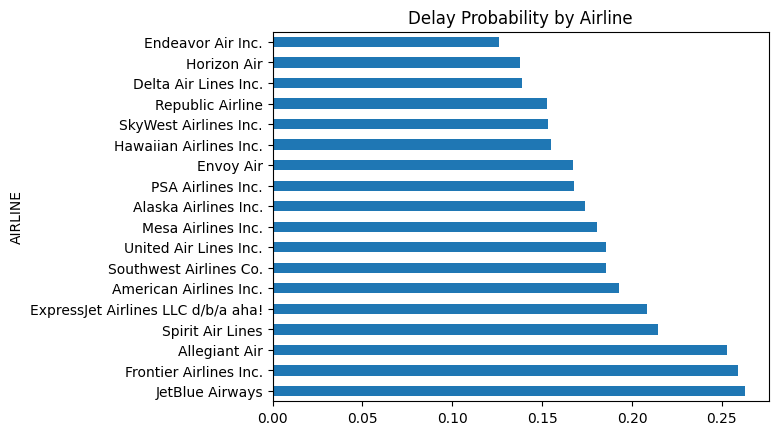

In [ ]:
delay_risk = (
    df.groupby('AIRLINE')['delay_flag']
    .mean()
    .sort_values(ascending=False)
)

delay_risk.plot(kind='barh', title="Delay Probability by Airline")
plt.show()


# This shows:
# “How often airline is delayed” (better than avg delay)

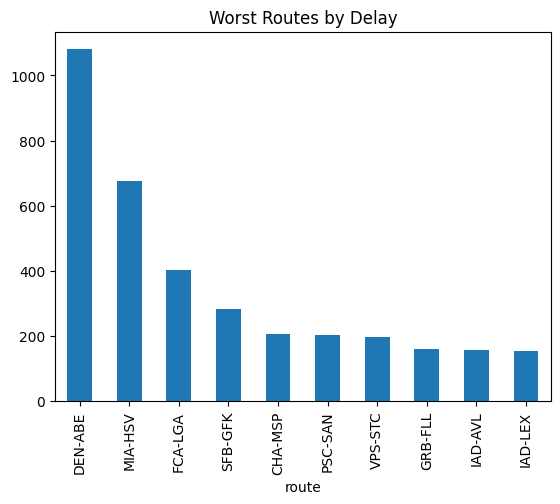

In [12]:
# route based delays

top_routes = (
    df.groupby('route')['ARR_DELAY']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_routes.plot(kind='bar', title="Worst Routes by Delay")
plt.show()

###  Worst Routes by Delay
What we see: DEN → ABE is extremely high (~1000+ avg delay) 🚨
Then:
MIA → HSV
FCA → LGA

####  Insight: Certain routes experience extreme delays, not just because of distance but likely due to connection chains, airport congestion, or scheduling inefficiencies.

###  Advanced interpretation:
DEN is a major hub → delays propagate
Smaller destinations (ABE, HSV) → less recovery capacity

###  Delay Probability by Airline (VERY IMPORTANT)

This is stronger than avg delay.

What we see:

- Worst (highest delay probability):
  - JetBlue
  - Frontier
  - Allegiant
  - Spirit
- Best:
  - Endeavor
  - Horizon
  - Delta
####  Insight: Low-cost carriers show significantly higher delay probabilities, indicating tighter scheduling and lower operational buffers compared to premium airlines.
